In [4]:
# Import all the necessary packages.
%reset -f
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# County-level summary used for modeling (written by an earlier cell or shipped in Data/).
DATA_CSV = Path("Data") / "pri_poverty_summary.csv"

# --- Raw Excel vs packaged CSV (always run this cell first; use Restart & Run All) ---
RAW_DIR = Path("Data/raw")
_RAW_EXCEL = [
    RAW_DIR / "ACSST5Y2019.S1701-2024-11-18T185757.xlsx",
    RAW_DIR / "ACSST5Y2020.S1701-2024-11-18T185806.xlsx",
    RAW_DIR / "ACSST5Y2021.S1701-2024-11-18T185811.xlsx",
    RAW_DIR / "Master data PUBLIC ACCESSIBLE.xlsx",
]
USE_RAW_PIPELINE = all(p.is_file() for p in _RAW_EXCEL)

if not USE_RAW_PIPELINE:
    pri_poverty_summary = pd.read_csv(DATA_CSV)
    pri_poverty_summary = pri_poverty_summary[
        pri_poverty_summary["County"] != "Statewide"
    ].copy()
    print(
        "Raw Excel files not under Data/raw/ — using",
        DATA_CSV.resolve(),
    )
else:
    print("Building county summary from Excel files in", RAW_DIR.resolve())


Raw Excel files not under Data/raw/ — using /Users/kirthi/Documents/UCBerkeley/kirthi_portfolio/MIDS/CountyLevel_PovertyPrediction_InCalifornia/Data/pri_poverty_summary.csv


## Load the Dataset and Combine

#### Loading 2019 Dataset for American Community Survey (ACS) 5-Year Estimates 

In [5]:
if USE_RAW_PIPELINE:
    # These commands below set some options for pandas and to have matplotlib show the charts in the notebook
    pd.set_option('display.max_rows', 1000)
    pd.options.display.float_format = '{:,.2f}'.format

    # Load the data
    acs2019 = pd.read_excel(RAW_DIR / 'ACSST5Y2019.S1701-2024-11-18T185757.xlsx', 'Data', index_col=False)

    # pull only the county name 
    acs_col_names = [x for x in acs2019.columns if 'Unnamed' not in x]

    # set row 0 as column names
    acs2019.columns = acs2019.iloc[0].fillna(' ')

    # set column 0 as index
    acs2019.set_index(acs2019.columns[0], inplace=True)

    # only keep columns with Poverty Rate data
    acs2019 = acs2019.loc[:, acs2019.columns.str.contains('Percent')]

    # set county names as column names
    acs2019.columns = acs_col_names

    # remove the first two rows
    acs2019 = acs2019.iloc[2:, :]

    # remove rows with NaN
    acs2019 = acs2019.dropna()

    # convert all text to float
    acs2019 = acs2019.map(lambda x: float(x.strip('%')) / 100 if x.endswith('%') else np.nan)

    # remove unnecessary data
    acs2019 = acs2019.drop(acs2019.index[4:22])
    acs2019 = acs2019.iloc[:11,:]

    # remove unnecesary words from column heading to match county names in the PRI table
    acs2019.columns = acs2019.columns.str.replace(r' County, California$', '', regex=True).str.replace('California', 'Statewide', regex=False)
    acs2019.head(20)

#### Loading 2020 Dataset for American Community Survey (ACS) 5-Year Estimates 

In [6]:
if USE_RAW_PIPELINE:
    # Load the data
    acs2020 = pd.read_excel(RAW_DIR / 'ACSST5Y2020.S1701-2024-11-18T185806.xlsx', 'Data', index_col=False)

    # pull only the county name 
    acs_col_names = [x for x in acs2020.columns if 'Unnamed' not in x]

    # set row 0 as column names
    acs2020.columns = acs2020.iloc[0].fillna(' ')

    # set column 0 as index
    acs2020.set_index(acs2020.columns[0], inplace=True)

    # only keep columns with Poverty Rate data
    acs2020 = acs2020.loc[:, acs2020.columns.str.contains('Percent')]

    # set county names as column names
    acs2020.columns = acs_col_names

    # remove the first two rows
    acs2020 = acs2020.iloc[2:, :]

    # remove rows with NaN
    acs2020 = acs2020.dropna()

    # convert all text to float
    acs2020 = acs2020.map(lambda x: float(x.strip('%')) / 100 if x.endswith('%') else np.nan)

    # remove unnecessary data
    acs2020 = acs2020.drop(acs2020.index[4:22])
    acs2020 = acs2020.iloc[:11,:]

    # remove unnecesary words from column heading to match county names in the PRI table
    acs2020.columns = acs2020.columns.str.replace(r' County, California$', '', regex=True).str.replace('California', 'Statewide', regex=False)
    acs2020.head(20)

#### Loading 2021 Dataset for American Community Survey (ACS) 5-Year Estimates 

In [7]:
if USE_RAW_PIPELINE:
    # Load the data
    acs2021 = pd.read_excel(RAW_DIR / 'ACSST5Y2021.S1701-2024-11-18T185811.xlsx', 'Data', index_col=False)

    # pull only the county name 
    acs_col_names = [x for x in acs2021.columns if 'Unnamed' not in x]

    # set row 0 as column names
    acs2021.columns = acs2021.iloc[0].fillna(' ')

    # set column 0 as index
    acs2021.set_index(acs2021.columns[0], inplace=True)

    # only keep columns with Poverty Rate data
    acs2021 = acs2021.loc[:, acs2021.columns.str.contains('Percent')]

    # set county names as column names
    acs2021.columns = acs_col_names

    # remove the first two rows
    acs2021 = acs2021.iloc[2:, :]

    # remove rows with NaN
    acs2021 = acs2021.dropna()

    # convert all text to float
    acs2021 = acs2021.map(lambda x: float(x.strip('%')) / 100 if x.endswith('%') else np.nan)

    # remove unnecessary data
    acs2021 = acs2021.drop(acs2021.index[4:22])
    acs2021 = acs2021.iloc[:11,:]

    # remove unnecesary words from column heading to match county names in the PRI table
    acs2021.columns = acs2021.columns.str.replace(r' County, California$', '', regex=True).str.replace('California', 'Statewide', regex=False)
    acs2021.head(11)


#### Loading CalFresh Program Reach Index (PRI) Data Set. Sourced from the California Department of Social Services, this dataset reports the percentage of eligible residents in each county who received CalFresh benefits.

In [8]:
if USE_RAW_PIPELINE:
    # Load the data
    pri = pd.read_excel(RAW_DIR / 'Master data PUBLIC ACCESSIBLE.xlsx', 'PRI', index_col=False)

    # set column 0 as index
    #pri.set_index(pri.columns[0], inplace=True)
    # set row 1 as column names
    pri.columns = pri.iloc[0].fillna(' ')
    # remove the first row and index name
    pri = pri.iloc[1:, :]
    pri.index.name = None
    # set row 1 as column names
    #pri.columns = pri.iloc[0].fillna(' ')
    pri.reset_index(inplace=True)
    # only keep columns with PRI data
    pri = pri[['Calendar Year', 'PRI Excludes SSI (SSI Removed From the Calculation)','County','County Center X','County Center Y']]

    pri = pri.rename(columns={'Calendar Year':'year','County Center X':'longitude','County Center Y':'latitude','PRI Excludes SSI (SSI Removed From the Calculation)':'PRI'})
    pri = pri.set_index('County')
    pri.head()

## Review the Data & Pre-process if required

#### Plotting County wise density map for PRI entry

In [9]:
if USE_RAW_PIPELINE:
    fig = px.density_mapbox(pri, lat='latitude', lon='longitude',
                            z='PRI', radius=15,
                            center=dict(lat=pri.latitude.mean(), 
                                        lon=pri.longitude.mean()), 
                            zoom=5,
                            mapbox_style="open-street-map", 
                            height=800)
    fig.update_geos(visible=False)
    fig.show()

In [10]:
if USE_RAW_PIPELINE:
    # only keep columns with PRI data
    pri = pri[['year', 'PRI']]
    pri.index.name = None
    pri.shape


In [11]:
if USE_RAW_PIPELINE:
    pri.head(10)

### Generate co-relation Matrix for ACS data

In [12]:
if USE_RAW_PIPELINE:
    acs2021

In [13]:
if USE_RAW_PIPELINE:
    acs2021.T.columns

In [14]:
if USE_RAW_PIPELINE:
    # combine three year poverty data into one dataframe
    # List of all column names to include
    columns_to_include = acs2021.T.columns.tolist()

    # Build the DataFrame
    poverty_new = pd.DataFrame({
        'County': pd.concat([
            acs2019.T.reset_index()['index'],
            acs2020.T.reset_index()['index'],
            acs2021.T.reset_index()['index']
        ]).values,
        'Calendar Year': ['2019'] * 59 + ['2020'] * 59 + ['2021'] * 59,
    })

    # Add each selected column from each year's dataset
    for col in columns_to_include:
        poverty_new[col] = pd.concat([
            acs2019.T[col],
            acs2020.T[col],
            acs2021.T[col]
        ]).values
    poverty_new.rename(columns={'Calendar Year':'year'},inplace=True)
    poverty_new['year']=poverty_new['year'].astype(str) 

    poverty_new

#### Plotting Correlation matrix for the Poverty data summarized so far. This data will be used for further analysis

In [15]:
if USE_RAW_PIPELINE:
    combined_acs =poverty_new.drop(['County','year'],axis=1)
    combined_acs.rename(columns={'Population for whom poverty status is determined':'Poverty Rate'},inplace=True)

    plt.figure(figsize = (12, 10))
    corr = combined_acs.corr()
    sns.heatmap(corr, cmap = 'viridis',annot = True,fmt = ".2f", square = True, linewidths = 0.5, cbar_kws = {"shrink": 0.8}) #3
    plt.title('Correlation Heatmap of Features (including Poverty Rate)', fontsize = 14, color = 'darkblue', fontweight = 'bold') #4
    plt.tight_layout()
    plt.show()



In [16]:
if USE_RAW_PIPELINE:
    combined_acs.corr()['Poverty Rate'].sort_values(ascending=False)

#### Combine three years COVID year data

In [17]:
if USE_RAW_PIPELINE:
    pri[pri['year'] == 2020]['PRI']

    # combine poverty rate data for all counties
    pri_combined = pd.DataFrame({
        '2019': pri[pri['year'] == 2019]['PRI'],
        '2020': pri[pri['year'] == 2020]['PRI'],
        '2021': pri[pri['year'] == 2021]['PRI']
        })

    pri_combined.head()

### Visualize Poverty Rate data distribution 

In [18]:
if USE_RAW_PIPELINE:
    # combine poverty rate data for all counties
    acs_combined = pd.DataFrame({
        '2019': acs2019.T['Population for whom poverty status is determined'],
        '2020': acs2020.T['Population for whom poverty status is determined'],
        '2021': acs2021.T['Population for whom poverty status is determined']
        })

    # get number of counties
    bar_num = np.arange(len(acs_combined)) * 2

    # set the width of each bar
    bar_width = 0.60

    # create the grouped bar chart
    plt.figure(figsize = (25, 6))
    plt.bar(bar_num - 0.60, acs_combined['2019'], bar_width, label = '2019', color ='orange')
    plt.bar(bar_num, acs_combined['2020'], bar_width, label = '2020', color ='blue')
    plt.bar(bar_num + 0.60, acs_combined['2021'], bar_width, label = '2021', color ='yellow')
    plt.xticks(bar_num, acs_combined.index, fontsize = 10, rotation = 45, ha = 'right')

    # Add labels, title, and legend
    plt.title('Poverty Rate from 2019-2021', fontsize=16)
    plt.xlabel('County Name', fontsize=12)
    plt.ylabel('Poverty Rate', fontsize=12)
    plt.legend()

In [19]:
if USE_RAW_PIPELINE:
    acs_combined

In [20]:
if USE_RAW_PIPELINE:
    # create DF of california poverty from 2019-2021
    CA_poverty_rate = pd.DataFrame({
        '2019': acs2019.loc[:, 'Statewide'],
        '2020': acs2020.loc[:, 'Statewide'],
        '2021': acs2021.loc[:, 'Statewide']
    })

    #plot the poverty rate
    CA_poverty_rate.loc['Population for whom poverty status is determined'].plot()
    plt.title('California Poverty')

    #plot the PRI
    CA_pri = pri.loc['Statewide', :]
    plt.figure(figsize=(5, 5))
    plt.plot(
        CA_pri["year"],
        CA_pri["PRI"]                                    
    ,color='g')
    plt.title('California PRI')

In [21]:
if USE_RAW_PIPELINE:
    # combine poverty rate data for all counties
    pri_combined = pd.DataFrame({
        '2019': pri[pri['year'] == 2019]['PRI'],
        '2020': pri[pri['year'] == 2020]['PRI'],
        '2021': pri[pri['year'] == 2021]['PRI']
        })
    pri_combined.head()


In [22]:
if USE_RAW_PIPELINE:
    # combine poverty rate data for all counties
    pri_combined = pd.DataFrame({
        '2019': pri[pri['year'] == 2019]['PRI'],
        '2020': pri[pri['year'] == 2020]['PRI'],
        '2021': pri[pri['year'] == 2021]['PRI']
        })

    # get number of counties
    bar_num = np.arange(len(pri_combined)) * 2

    # set the width of each bar
    bar_width = 0.60

    # create the grouped bar chart
    plt.figure(figsize = (25, 6))
    plt.bar(bar_num - 0.60, pri_combined['2019'], bar_width, label = '2019', color ='orange')
    plt.bar(bar_num, pri_combined['2020'], bar_width, label = '2020', color ='blue')
    plt.bar(bar_num + 0.60, pri_combined['2021'], bar_width, label = '2021', color ='yellow')
    plt.xticks(bar_num, pri_combined.index, fontsize = 10, rotation = 45, ha = 'right')

    # Add labels, title, and legend
    plt.title('CalFresh Program Reach Index (PRI) from 2019-2021', fontsize=16)
    plt.xlabel('County Name', fontsize=12)
    plt.ylabel('PRI', fontsize=12)
    plt.legend()

In [23]:
if USE_RAW_PIPELINE:
    # acs_combined = pd.DataFrame({
    #     '2019': acs2019.T['Population for whom poverty status is determined'],
    #     '2020': acs2020.T['Population for whom poverty status is determined'],
    #     '2021': acs2021.T['Population for whom poverty status is determined']
    #     })

    # combine three year poverty data into one dataframe
    poverty_new = pd.DataFrame({
        'County': pd.concat([
            acs2019.T.reset_index()['index'],
            acs2020.T.reset_index()['index'],
            acs2021.T.reset_index()['index']
        ]).values,
        'year': ['2019'] * 59 + ['2020'] * 59 + ['2021'] * 59,
        'Poverty Rate': pd.concat([
            acs2019.T['Population for whom poverty status is determined'],
            acs2020.T['Population for whom poverty status is determined'],
            acs2021.T['Population for whom poverty status is determined']
        ]).values,
        'Under 18 Years': pd.concat([
            acs2019.T['Under 18 years'],
            acs2020.T['Under 18 years'],
            acs2021.T['Under 18 years']
        ]).values,
        'Under 5 Years': pd.concat([
            acs2019.T['Under 5 years'],
            acs2020.T['Under 5 years'],
            acs2021.T['Under 5 years']
        ]).values,
        'Less than high school graduate': pd.concat([
            acs2019.T['Less than high school graduate'],
            acs2020.T['Less than high school graduate'],
            acs2021.T['Less than high school graduate']
        ]).values,
        'Unemployed': pd.concat([
            acs2019.T['Unemployed'],
            acs2020.T['Unemployed'],
            acs2021.T['Unemployed']
        ]).values,
    })

    # merge pri data into the dataframe
    pri_data = pri[(pri['year'] == 2019) | (pri['year'] == 2020) | (pri['year'] == 2021)].rename_axis('County').reset_index()
    pri_data['year'] = pri_data['year'].astype(str) #convert year to str to match type with poverty data
    pri_poverty = pd.merge(poverty_new, pri_data, on=['County', 'year'], how='left')

    pri_poverty.head()


### Aggregate all the combined data set to average out the Poverty Rate 

In [24]:
if USE_RAW_PIPELINE:
    pri_poverty['PRI'] = pri_poverty['PRI'].astype('float')

    # calculate state average 
    avg_poverty = pri_poverty.groupby('County')['Poverty Rate'].mean()['Statewide']
    avg_pri = pri_poverty.groupby('County')['PRI'].mean()['Statewide']


In [25]:
if USE_RAW_PIPELINE:
    # calculate state average 
    # avg_poverty = pri_poverty.groupby('County')['Poverty Rate'].mean()['Statewide']
    # avg_pri = pri_poverty.groupby('County')['PRI Excludes SSI (SSI Removed From the Calculation)'].mean()['Statewide']

    pri_poverty_summary = pri_poverty.groupby('County', as_index=False).agg({
        'Poverty Rate': 'mean',
        'PRI':'mean',
        'Under 18 Years': 'mean',
        'Under 5 Years': 'mean',
        'Less than high school graduate': 'mean',
        'Unemployed': 'mean'
    })

    pri_poverty_summary.columns = ['County', 'Average Poverty Rate', 'Average PRI','Avg Proportion of Under 18yo', 'Avg Proportion of Under 5yo', 'Avg Proportion of No HS Diploma', 'Avg Unemployed' ]

    # Categorize counties based on CA average
    def categorize(row):
        if row['Average PRI'] >= avg_pri and row['Average Poverty Rate'] <= avg_poverty:
            return "High PRI & Low Poverty (Potential Impact)"
        elif row['Average PRI'] < avg_pri and row['Average Poverty Rate'] > avg_poverty:
            return "Low PRI & High Poverty (Potential Target)"
        elif row['Average PRI'] >= avg_pri and row['Average Poverty Rate'] > avg_poverty:
            return "High PRI & High Poverty (No Impact)"
        else:
            return "Low PRI & Low Poverty (No Impact)"

    pri_poverty_summary['Category'] = pri_poverty_summary.apply(categorize, axis=1)
    pri_poverty_summary.head(10)

In [26]:
if USE_RAW_PIPELINE:
    # Count the number of counties in each category
    category_counts = pri_poverty_summary['Category'].value_counts()
    print('Count of categories')
    print(category_counts.head())

    # Group by category and calculate averages
    category_stats = pd.DataFrame(pri_poverty_summary.groupby('Category')[[
        'Average Poverty Rate', 
        'Average PRI', 
        'Avg Proportion of Under 18yo', 
        'Avg Proportion of Under 5yo', 
        'Avg Proportion of No HS Diploma', 
        'Avg Unemployed'
    ]].mean())
    plt.figure(figsize=(5, 5))
    category_stats.plot.bar(colormap='plasma')
    category_stats.head()

In [27]:
if USE_RAW_PIPELINE:
    # calculate state average 
    # avg_poverty = pri_poverty.groupby('County')['Poverty Rate'].mean()['Statewide']
    # avg_pri = pri_poverty.groupby('County')['PRI Excludes SSI (SSI Removed From the Calculation)'].mean()['Statewide']

    pri_poverty_summary = pri_poverty.groupby('County', as_index=False).agg({
        'Poverty Rate': 'mean',
        'PRI':'mean',
        'Under 18 Years': 'mean',
        'Under 5 Years': 'mean',
        'Less than high school graduate': 'mean',
        'Unemployed': 'mean'
    })

    pri_poverty_summary.columns = ['County', 'Average Poverty Rate', 'Average PRI','Avg Proportion of Under 18yo', 'Avg Proportion of Under 5yo', 'Avg Proportion of No HS Diploma', 'Avg Unemployed' ]

    # Categorize counties based on CA average
    def categorize(row):
        if row['Average PRI'] >= avg_pri and row['Average Poverty Rate'] <= avg_poverty:
            return "High PRI & Low Poverty (Potential Impact)"
        elif row['Average PRI'] < avg_pri and row['Average Poverty Rate'] > avg_poverty:
            return "Low PRI & High Poverty (Potential Target)"
        elif row['Average PRI'] >= avg_pri and row['Average Poverty Rate'] > avg_poverty:
            return "High PRI & High Poverty (No Impact)"
        else:
            return "Low PRI & Low Poverty (No Impact)"

    pri_poverty_summary['Category'] = pri_poverty_summary.apply(categorize, axis=1)
    pri_poverty_summary.head(10)

##### The Poverty Data is saved as csv file to review & experiment with various models. Hence its loaded again in the below cell.

In [28]:
if USE_RAW_PIPELINE:
    # Removing statewide data. We need only county wise data for our analysis 
    pri_poverty_summary = pri_poverty_summary[pri_poverty_summary['County'] != 'Statewide']

In [29]:
if USE_RAW_PIPELINE:
    # Save the DataFrame to a CSV file under Data/ (directory created if needed).
    DATA_CSV.parent.mkdir(parents=True, exist_ok=True)
    pri_poverty_summary.to_csv(DATA_CSV, index=False)


In [30]:
pri_poverty_summary.columns

Index(['County', 'Average Poverty Rate', 'Average PRI',
       'Avg Proportion of Under 18yo', 'Avg Proportion of Under 5yo',
       'Avg Proportion of No HS Diploma', 'Avg Unemployed', 'Category'],
      dtype='str')

In [31]:
# final_withoutyear =pri_poverty_summary.drop(['County','Category'],axis=1)
# plt.figure(figsize = (5,5))
# corr = final_withoutyear.corr()
# sns.heatmap(corr, cmap = 'viridis')


#### From the correlation structure above, at first glance average poverty rate appears correlated with PRI. We revisit this after model evaluation.


# Model Building Starts here

In [32]:
# Re-read the data from CSV file stored above
# Assign X [features] & y [target]
def prepare_data():
    path = DATA_CSV if DATA_CSV.is_file() else Path("pri_poverty_summary.csv")
    if not path.is_file():
        raise FileNotFoundError(
            f"Could not find pri_poverty_summary.csv at {DATA_CSV} or ./pri_poverty_summary.csv. "
            "Run the data-prep cells above or use the file shipped under Data/."
        )
    df = pd.read_csv(path)
    X = df.drop(["County", "Average Poverty Rate", "Category"], axis=1)
    y = df["Average Poverty Rate"].values
    return X, y


## Load Data and Calculate Baseline model

In [33]:


# Assuming you have X_train and y_train ready
# X_train should be your feature DataFrame
# y_train should be your target DataFrame
    
print("Loading Data  & Preparing Train and val dataset")
print("=" * 60) 

X,y = prepare_data()
print("Printing the shape of the features :",X.shape)
print("Printing the shape of Target :",y.shape)

#Baseline model
#Create a prediction using mean poverty rate
Y_pred = [y.mean()] * len(X)
baseline_mse = mean_squared_error(y, Y_pred) # compute baseline

print(f'Baseline MSE: {baseline_mse:.5f}')

Loading Data  & Preparing Train and val dataset
Printing the shape of the features : (58, 5)
Printing the shape of Target : (58,)
Baseline MSE: 0.00192


## Build Model 

### Random Forest with K-fold cross-validation

There are only **58 California counties** in this table after removing the statewide row, so **5-fold CV is noisy** (small validation folds, high variance across folds). Treat metrics as indicative, not definitive. Alternatives worth exploring in extensions: **leave-one-out CV**, repeated K-fold, or explicitly spatial holdouts.


In [34]:

def kfold_random_forest(X, y,baseline_mse, k=5, n_estimators=100, max_depth=10):
    """
    Simple Random Forest with K-Fold validation
    Target: Beat the mean-of-y baseline MSE
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=1234)
    val_mses = []
    fold_predictions = [] 
    #improvemnts  
    print(f"Random Forest - {k}-Fold Cross Validation")
    print("-" * 50)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        # Split the data
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Create and train model
        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1
        )
        
        model.fit(X_train, y_train)
        
        # Predict and calculate MSE
        y_pred = model.predict(X_val)
        val_mse = mean_squared_error(y_val, y_pred)
        val_mses.append(val_mse)
        # Store predictions for plotting
        fold_predictions.extend(list(zip(y_val, y_pred)))
        print(f'Fold {fold+1} Val MSE: {val_mse:.6f}')
    
    avg_mse = np.mean(val_mses)
    std_mse = np.std(val_mses)
    
    
    print("-" * 50)
    print(f'Average MSE: {avg_mse:.6f} (±{std_mse:.6f})')
    print(f'Baseline MSE: {baseline_mse:.6f}')
    
    if avg_mse < baseline_mse:
        improvement = ((baseline_mse - avg_mse) / baseline_mse) * 100
        print(f'Improvement Achieved [ Avg MSE is < Baseline MSE]: {improvement:.2f}%')
    else:
        print('Did not beat baseline')
    
    return avg_mse, val_mses, model,fold_predictions

### Prepare Train & Val split and Run Random Forest Model
#### Review the model performance against Baseline

In [35]:
# Prepare Training , Val split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

print("Running Random Forest Model using K-fold cross validation")
print("=" * 60)
# We will keep the k-fold small
avg_mse, val_mses,model,fold_predictions = kfold_random_forest(X_train, y_train,baseline_mse, k=5)

# Summarising the K-fold result
print(f"\n" + "=" * 70)
print("FOLD-BY-FOLD RESULTS WITH ANALYSIS:")
print("=" * 70)

# Calculate the best and worst MSE
best_mse = min(val_mses)
worst_mse = max(val_mses) 


for i, score in enumerate(val_mses):
				fold_num = i
				mse = score
				
				improvement = ((baseline_mse - mse) / baseline_mse) * 100 
				# Determine status
				status_parts = []
	
				if mse == best_mse:
								status_parts.append("Best fold")
				if mse == worst_mse:
								status_parts.append("Worst fold")
				if improvement >= 85:
								status_parts.append("Excellent!")
				elif improvement >= 75:
								status_parts.append("Very good")
				elif improvement >= 60:
								status_parts.append("Good")
				
				# Format status
				status = " ← " + ", ".join(status_parts) if status_parts else ""
				
				print(f'Fold {fold_num} Val MSE: {mse:.6f} ({improvement:.0f}% better than baseline){status}')

model_name = "Random Forest"

#fdor name, mse in sorted(results, key=lambda x: x[1]):
status = f"{model_name} BEATS BASELINE" if avg_mse < baseline_mse else f"{model_name} is Below baseline"
print(f"{model_name:20} AVG MSE: {avg_mse:.6f} - {status}")

# TRAIN FINAL MODEL
print(f"\n2. FINAL MODEL TRAINING:")
print("-" * 40)

final_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

Running Random Forest Model using K-fold cross validation
Random Forest - 5-Fold Cross Validation
--------------------------------------------------
Fold 1 Val MSE: 0.000515
Fold 2 Val MSE: 0.000201
Fold 3 Val MSE: 0.000640
Fold 4 Val MSE: 0.000757
Fold 5 Val MSE: 0.000305
--------------------------------------------------
Average MSE: 0.000484 (±0.000206)
Baseline MSE: 0.001924
Improvement Achieved [ Avg MSE is < Baseline MSE]: 74.85%

FOLD-BY-FOLD RESULTS WITH ANALYSIS:
Fold 0 Val MSE: 0.000515 (73% better than baseline) ← Good
Fold 1 Val MSE: 0.000201 (90% better than baseline) ← Best fold, Excellent!
Fold 2 Val MSE: 0.000640 (67% better than baseline) ← Good
Fold 3 Val MSE: 0.000757 (61% better than baseline) ← Worst fold, Good
Fold 4 Val MSE: 0.000305 (84% better than baseline) ← Very good
Random Forest        AVG MSE: 0.000484 - Random Forest BEATS BASELINE

2. FINAL MODEL TRAINING:
----------------------------------------


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Model Evaluation

In [36]:

print(f"\n Starting Model Evaluation:")
print("-" * 40)


# Training predictions
y_train_pred = final_model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)

# Test predictions
y_test_pred = final_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Training Metrics:")
print("*" * 20)
print(f"  MSE: {train_mse:.6f}")
print(f"  R²:  {train_r2:.4f}")
print(f"  MAE: {train_mae:.6f}")

print(f"Test Metrics:")
print("*" * 20)
print(f"  MSE: {test_mse:.6f}")
print(f"  R²:  {test_r2:.4f}")
print(f"  MAE: {test_mae:.6f}")

test_improvement = ((baseline_mse - test_mse) / baseline_mse) * 100
print(f"Test Improvement over baseline: {test_improvement:.1f}%")


 Starting Model Evaluation:
----------------------------------------
Training Metrics:
********************
  MSE: 0.000066
  R²:  0.9675
  MAE: 0.005862
Test Metrics:
********************
  MSE: 0.000090
  R²:  0.9063
  MAE: 0.007861
Test Improvement over baseline: 95.3%


### Visualisation of the Result using various plot


 Visualize the Result
------------------------------


/var/folders/qv/qlfwtdns4gv03fldlrywcz2c0000gn/T/ipykernel_49911/2037335725.py:38: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,color='blue')


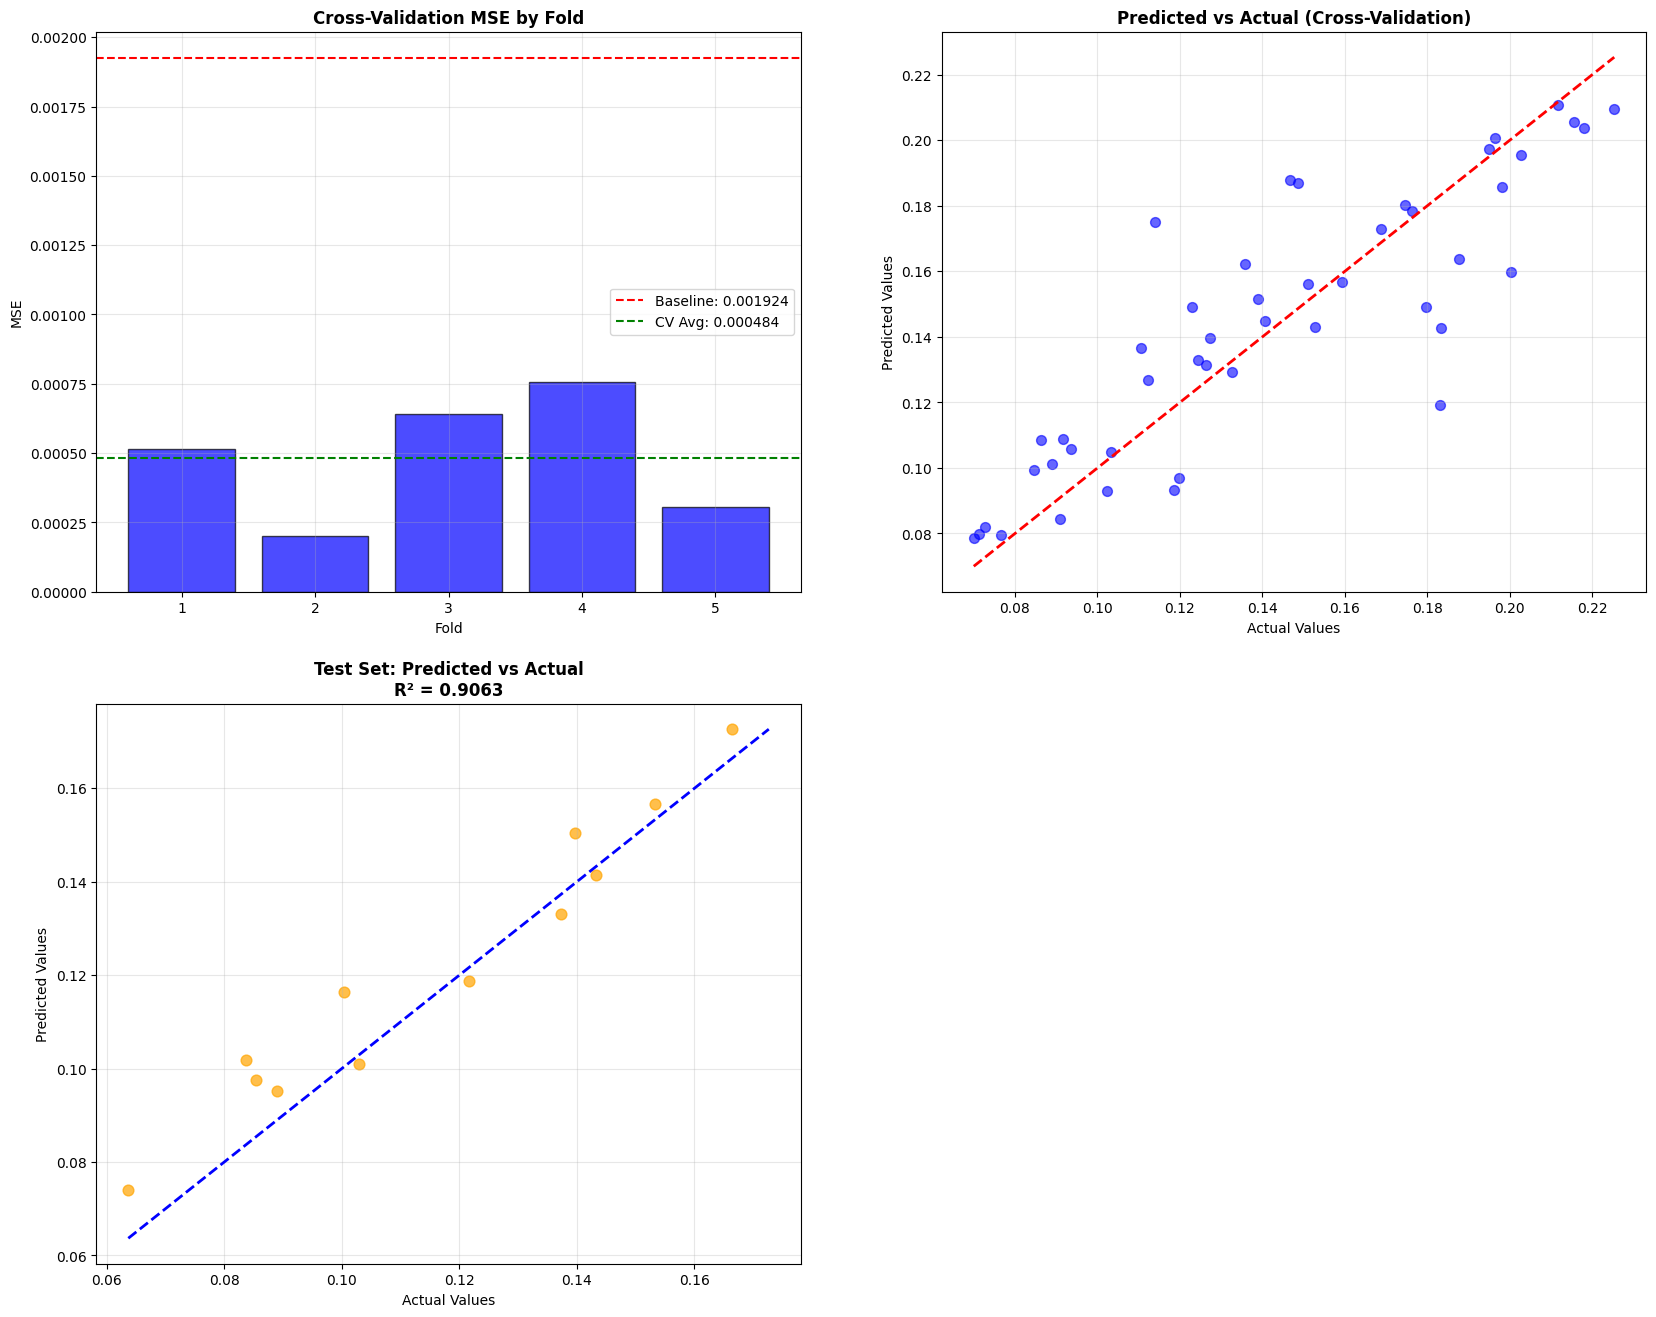

In [37]:
# Start generating plots
print(f"\n Visualize the Result")
print("-" * 30)
fig = plt.figure(figsize=(20, 16))

# Cross-Validation Score Plot
ax1 = plt.subplot(2, 2, 1)
folds = range(1, 6)
plt.bar(folds, val_mses, alpha=0.7, color='blue', edgecolor='black')
plt.axhline(y=baseline_mse, color='red', linestyle='--', label=f'Baseline: {baseline_mse:.6f}')
plt.axhline(y=avg_mse, color='green', linestyle='--', label=f'CV Avg: {avg_mse:.6f}')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.title('Cross-Validation MSE by Fold',weight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Predicted vs Actual [ Cross Validation] Plot
ax2 = plt.subplot(2, 2, 2)
cv_actual, cv_predicted = zip(*fold_predictions)
plt.scatter(cv_actual, cv_predicted, alpha=0.6, s=50,color='blue')
min_val = min(min(cv_actual), min(cv_predicted))
max_val = max(max(cv_actual), max(cv_predicted))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual (Cross-Validation)',weight='bold')
plt.grid(True, alpha=0.3)




# Test Set - Predicted vs Actual Plot
ax7 = plt.subplot(2, 2, 3)
plt.scatter(y_test, y_test_pred, alpha=0.7, s=60, c='orange')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,color='blue')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Test Set: Predicted vs Actual\nR² = {test_r2:.4f}',weight='bold')
plt.grid(True, alpha=0.3)



    

### Feature Importance gained from Random Forest Best K-Fold Model 


 Most important Features as per the model :
----------------------------------------
Top 10 Most Important Features:
                           Feature  Importance
1     Avg Proportion of Under 18yo      0.6291
2      Avg Proportion of Under 5yo      0.2600
3  Avg Proportion of No HS Diploma      0.0472
4                   Avg Unemployed      0.0444
0                      Average PRI      0.0193


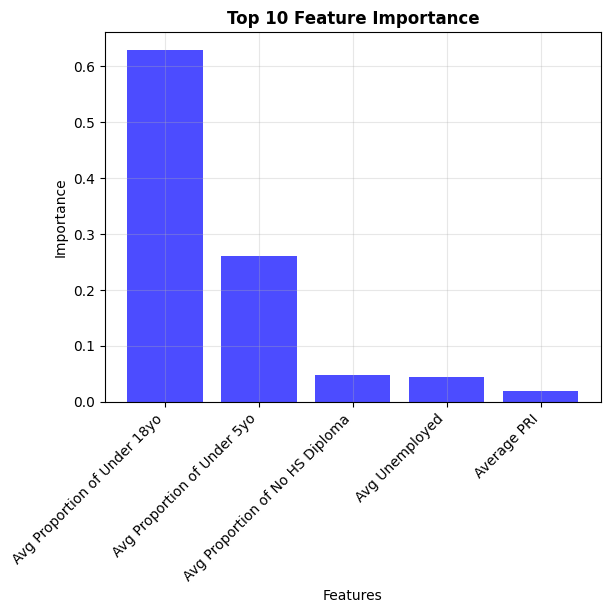

In [38]:
print(f"\n Most important Features as per the model :")
print("-" * 40)

importance_df = pd.DataFrame({
				'Feature': X.columns,
				'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("=" * 40) 
print("Top 10 Most Important Features:")
print("=" * 40)
print(importance_df.head(10).round(4))

# Feature Importance Plot

feature_importance = final_model.feature_importances_
feature_names = X.columns
indices = np.argsort(feature_importance)[::-1][:10]  # Top 10 features

plt.bar(range(len(indices)), feature_importance[indices], alpha=0.7,color='blue')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Top 10 Feature Importance',weight='bold')
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.grid(True, alpha=0.3)